# Combined Recommendation System

combining multiple recommenders with weighted scores. easy to add new ones later

In [1]:
%load_ext autoreload
%autoreload 2

## setup and data loading

first connect to db and load all the data we need

In [2]:
import os
import asyncio
import asyncpg
from dotenv import load_dotenv
import pandas as pd
from urllib.parse import urlparse, parse_qs, urlencode, urlunparse

load_dotenv()
DATABASE_URL = os.getenv('DATABASE_URL')
if (DATABASE_URL is None):
    raise ValueError("DATABASE_URL is not set in environment variables")


def remove_schema_param(url):
    parsed = urlparse(url)
    query_params = parse_qs(parsed.query)

    query_params.pop('schema', None)

    new_query = urlencode(query_params, doseq=True)
    new_parsed = parsed._replace(query=new_query)
    return urlunparse(new_parsed)

asyncpg_url = remove_schema_param(DATABASE_URL)
conn = await asyncpg.connect(dsn=asyncpg_url)

In [3]:
from collaborative_filtering.utils import load_trade_tags

if not os.path.exists('models'):
    os.makedirs('models')

print("Loading Trade Data ")
user_trades_df = load_trade_tags("collaborative_filtering/df_trade_tags_cache")

len(user_trades_df)

Loading Trade Data 
Loading from 142 parquet files in 'collaborative_filtering/df_trade_tags_cache/'...


14259585

In [4]:
trades = user_trades_df[['user_id', 'event_id', 'item', 'timestamp']].drop_duplicates()
trades = trades.sort_values(['user_id', 'timestamp'])

# compute split indices per user
trades['row_num'] = trades.groupby('user_id').cumcount()
trades['total'] = trades.groupby('user_id')['timestamp'].transform('size')
trades['cutoff'] = (trades['total'] * 0.8).astype(int).clip(lower=1, upper=trades['total']-1)


trades = trades[trades['total'] >= 2]

# split at event level
train_trades = trades[trades['row_num'] < trades['cutoff']].drop(columns=['row_num', 'total', 'cutoff'])
test_trades = trades[trades['row_num'] >= trades['cutoff']].drop(columns=['row_num', 'total', 'cutoff'])


train_tags = user_trades_df.merge(
    train_trades[['user_id', 'event_id', 'timestamp']], 
    on=['user_id', 'event_id', 'timestamp']
)
test_tags = user_trades_df.merge(
    test_trades[['user_id', 'event_id', 'timestamp']], 
    on=['user_id', 'event_id', 'timestamp']
)

print(f"train trades: {len(train_trades):,}, test trades: {len(test_trades):,}")
print(f"train tags: {len(train_tags):,}, test tags: {len(test_tags):,}")


train trades: 1,818,836, test trades: 458,898
train tags: 12,176,402, test tags: 2,694,197


recommenders setup

Loading/Training CF model with: Factors=64, Reg=1.0, Iterations=40...
  591,463 user-tag pairs
  matrix: 8380 x 3680


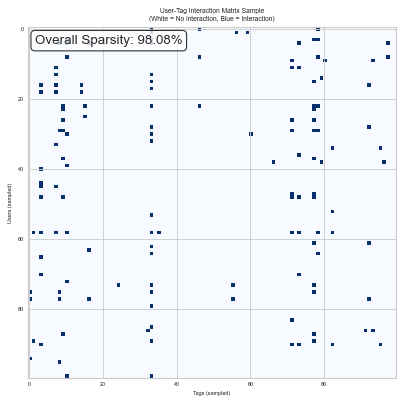

100%|██████████| 40/40 [00:03<00:00, 10.97it/s]


Mapping events...
Loading from 7 parquet files in 'events_tag_cache/'...
  29331 events mapped
sparsity: 0.9808 (98.08%)


In [ ]:
# Collaborative filtering  setup
from collaborative_filtering.cf_recommender import load_cf_model

cf_model = load_cf_model(
    train_tags, 
    factors=64,           # 128 causes overfitting 
    regularization=1.0,   # moderate regularization works best
    iterations=40,        # 40 is sufficient
    alpha=100             # high confidence weighting helps
)


In [5]:
event_popularity = train_trades.groupby('event_id')['user_id'].nunique().reset_index()
event_popularity.columns = ['event_id', 'num_users']
event_popularity = event_popularity.sort_values('num_users', ascending=False)
event_popularity['event_id'] = event_popularity['event_id'].astype(str)

print(f"\nBaseline recommender: {len(event_popularity)} events ranked by popularity")

def recommend_popular_events(user_address, user_train_df, top_n=10):
    if user_train_df.empty:
        user_events_set = set()
    else:
        user_events_set = set(str(e) for e in user_train_df['event_id'].dropna())

    available_events = event_popularity[~event_popularity['event_id'].isin(user_events_set)]

    top_events = available_events.head(top_n)
    recommendations = [
        {'id': row['event_id'], 'score': row['num_users']} 
        for _, row in top_events.iterrows()
    ]
    
    return recommendations

c:\Users\euseb\anaconda3\envs\t2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading/Training CF model with: Factors=64, Reg=1.0, Iterations=40...
  591,463 user-tag pairs
  matrix: 8380 x 3680


c:\Users\euseb\anaconda3\envs\t2\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 40/40 [00:03<00:00, 12.25it/s]


Mapping events...
Loading from 7 parquet files in 'events_tag_cache/'...
  29331 events mapped
sparsity: 0.9808 (98.08%)

Baseline recommender: 29331 events ranked by popularity


In [6]:
# Topic-based setup
import faiss
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import pickle
import math

from utils import load_events_df, load_user_event_associations

index_path = "event_embeddings_shard_"
meta_path = "models/event_index_meta.pkl"
model_name_label = "all-MiniLM-L6-v2"

async def setup_topic_model(conn, train_trades, force_rebuild=False):
    # conn = await asyncpg.connect(dsn=os.getenv('DATABASE_URL').replace('?schema=public', ''))
   
    events_df = await load_events_df(conn, train_trades)
    train_event_ids = set(events_df.index)
    # user_event_associations_df = await load_user_event_associations(conn)
    
    
    if os.path.exists(meta_path) and not force_rebuild:
        # load faiss from cache
        with open(meta_path, "rb") as f:
            meta = pickle.load(f)
        
        cached_index_to_id = meta["index_to_id"]
        cached_id_to_index = meta["id_to_index"]
        
        # check if cached index matches train events
        cached_event_ids = set(cached_index_to_id.values())
        if cached_event_ids != train_event_ids:
            print(f"Cache mismatch: {len(cached_event_ids)} cached vs {len(train_event_ids)} train events")
            print("Rebuilding index...")
            return await setup_topic_model(conn, train_trades, True)

        index_to_id = cached_index_to_id
        id_to_index = cached_id_to_index
        
        # load shards
        indices = []
        shard_paths = sorted(p for p in os.listdir("models") if p.startswith("event_embeddings_shard_"))
        for p in shard_paths:
            indices.append(faiss.read_index(os.path.join("models", p)))
        
        # rebuild combined index
        d = indices[0].d
        index = faiss.IndexFlatIP(d)
        for idx in indices:
            n = idx.ntotal
            if hasattr(idx, "reconstruct_n"):
                xb = idx.reconstruct_n(0, n)
            else:
                xb = np.vstack([idx.reconstruct(i) for i in range(n)])
            index.add(xb.astype("float32"))
        
        if hasattr(index, "reconstruct_n"):
            normalized_embeddings = index.reconstruct_n(0, index.ntotal)
        else:
            normalized_embeddings = np.vstack([index.reconstruct(i) for i in range(index.ntotal)])
        
        print(f"Loaded FAISS index with {index.ntotal} events")
             
    else:
        print("building indexes...")
        

        # build embeddings
        embedding_model = SentenceTransformer(model_name_label)
        embeddings = embedding_model.encode(events_df['combined_text'].tolist(), show_progress_bar=True)
        
        normalized_embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
        
        # build FAISS index
        embedding_dim = embeddings.shape[1]
        index = faiss.IndexFlatIP(embedding_dim)
        index.add(normalized_embeddings.astype('float32'))
        
        index_to_id = {i: id for i, id in enumerate(events_df.index)}
        id_to_index = {id: i for i, id in enumerate(events_df.index)}
        
        print(f'FAISS index built with {index.ntotal} events')
        
        # save shards
        emb = normalized_embeddings.astype("float32")
        n, d = emb.shape
        shard_size = 15000
        n_shards = math.ceil(n / shard_size)
        
        for shard_id in range(n_shards):
            start = shard_id * shard_size
            end = min(start + shard_size, n)
            part = emb[start:end]
            
            idx = faiss.IndexFlatIP(d)
            idx.add(part)
            faiss.write_index(idx, f"models/event_embeddings_shard_{shard_id:02d}.index")
        
        meta = {
            "index_to_id": index_to_id,
            "id_to_index": id_to_index,
            "model_name": model_name_label,
        }
        with open(meta_path, "wb") as f:
            pickle.dump(meta, f)
        

    return events_df, index, index_to_id, id_to_index, normalized_embeddings
    
# topic_data = await setup_topic_model()
topic_data = await setup_topic_model(conn, train_trades)
events_df, index, index_to_id, id_to_index, normalized_embeddings = topic_data

Loading from 3 parquet files in 'data/events_df_cache/'...
Loaded 65056 events from cache
Filtered to 29331 events from train set
Loaded FAISS index with 29331 events


Here is our combined recommender:

In [8]:
def normalize_scores(recommendations):
    if not recommendations:
        return []
    
    scores = [r['score'] for r in recommendations]
    min_s, max_s = min(scores), max(scores)
    
    # Range to normalize to
    LOWER_BOUND = 0
    UPPER_BOUND = 1.0
    
    if max_s == min_s:
        return [{'id': r['id'], 'score': UPPER_BOUND} for r in recommendations]
        
    return [
        {
            'id': r['id'], 
            'score': LOWER_BOUND + (r['score'] - min_s) * (UPPER_BOUND - LOWER_BOUND) / (max_s - min_s)
        }
        for r in recommendations
    ]



In [9]:
item_to_event_id = train_trades.dropna(subset=['item', 'event_id']).set_index('item')['event_id'].to_dict()

In [10]:
from topic_based_recommender.recommend_events_for_user_by_topic_based import recommend_events_for_user_by_topic_based
from recommendation_system.main import get_recommendations_for_user, get_recommendations_for_user_fast
from collaborative_filtering.cf_recommender import recommend_events
from collections import defaultdict

def get_combined_recommendations(user_address, user_train_df, top_n=10):
    weights = {'cf': 0.1, 'apriori': 0.35, 'topic': 0.55, 'baseline': 0.0}
    
    final_scores = defaultdict(float)
    contributions = defaultdict(dict) # Store contribution details
    
    # Store individual recommendations for evaluation
    individual_recs = {
        'cf': [],
        'apriori': [],
        'topic': [],
        'baseline': []
    }

    already_traded = set(str(e) for e in user_train_df['event_id'].dropna()) if not user_train_df.empty else set()
    
    # Collaborative filtering
    try:
        cf_raw = recommend_events(user_address, n=40)  # lookup from pre-trained
        if cf_raw:
            cf_raw = [r for r in cf_raw if str(r['id']) not in already_traded][:20]  # filter
            
            if cf_raw:
                cf_recs = [{'id': str(r['id']), 'score': r['score']} for r in cf_raw]
                individual_recs['cf'] = [r['id'] for r in cf_recs[:top_n]]
                
                cf_norm = normalize_scores(cf_recs)
                for r in cf_norm:
                    weighted_score = r['score'] * weights['cf']
                    final_scores[r['id']] += weighted_score
                    contributions[r['id']]['cf'] = {'raw': r['score'], 'weighted': weighted_score}
    except Exception as e:
        print(e)
        pass

    # Association Rules
    ap_raw = get_recommendations_for_user_fast(user_address) 
    if ap_raw:
        ap_recs = []
        for r in ap_raw:
            m_item = r['recommended_market']
            if m_item in item_to_event_id:
                eid = str(item_to_event_id[m_item])
                if eid not in already_traded:  # filter
                    ap_recs.append({'id': eid, 'score': r['confidence']})
        
        if ap_recs:
            individual_recs['apriori'] = [r['id'] for r in ap_recs[:top_n]]
            
            ap_norm = normalize_scores(ap_recs)
            for r in ap_norm:
                weighted_score = r['score'] * weights['apriori']
                final_scores[r['id']] += weighted_score
                contributions[r['id']]['apriori'] = {'raw': r['score'], 'weighted': weighted_score}

    # Topic Based
    if not user_train_df.empty:
        user_event_history = user_train_df[['address', 'event_id']].dropna().drop_duplicates()
        
        if not user_event_history.empty:
            user_event_history['name'] = 'user'
            user_event_history['pseudonym'] = 'user'
            
            try:
                # user_event_history is INPUT - finds events similar to these
                topic_raw = recommend_events_for_user_by_topic_based(
                    id_to_index, normalized_embeddings, index, index_to_id, 
                    user_event_history,  # ← this is the input, not just for filtering
                    events_df, 
                    user_address, top_n=40, similar_per_event=5
                )
                
                if topic_raw:
                    topic_raw = [r for r in topic_raw if str(r['id']) not in already_traded][:20]  # filter
                    
                    if topic_raw:
                        topic_recs = [{'id': str(r['id']), 'score': r['total_score']} for r in topic_raw]
                        individual_recs['topic'] = [r['id'] for r in topic_recs[:top_n]]
                        
                        topic_norm = normalize_scores(topic_recs)
                        for r in topic_norm:
                            weighted_score = r['score'] * weights['topic']
                            final_scores[r['id']] += weighted_score
                            contributions[r['id']]['topic'] = {'raw': r['score'], 'weighted': weighted_score}
            except Exception as e:
                pass


    baseline_raw = recommend_popular_events(user_address, user_train_df, top_n=40)
    if baseline_raw:
        baseline_raw = [r for r in baseline_raw if str(r['id']) not in already_traded][:20]  # filter
        
        if baseline_raw:
            baseline_recs = [{'id': str(r['id']), 'score': r['score']} for r in baseline_raw]
            individual_recs['baseline'] = [r['id'] for r in baseline_recs[:top_n]]
            
            if weights['baseline'] > 0:
                baseline_norm = normalize_scores(baseline_recs)
                for r in baseline_norm:
                    weighted_score = r['score'] * weights['baseline']
                    final_scores[r['id']] += weighted_score
                    contributions[r['id']]['baseline'] = {'raw': r['score'], 'weighted': weighted_score}

    results = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
    combined_recs = [{'id': i, 'score': s, 'contributions': contributions[i]} for i, s in results[:top_n]]
    
    return combined_recs, individual_recs

In [11]:

total_users = 0
k = 10

results = {
    'combined': {'precisions': [], 'hits': 0},
    'cf': {'precisions': [], 'hits': 0},
    'apriori': {'precisions': [], 'hits': 0},
    'topic': {'precisions': [], 'hits': 0},
    'baseline': {'precisions': [], 'hits': 0}
}

train_trades_renamed = train_trades.rename(columns={'user_id': 'address'})
test_trades_renamed = test_trades.rename(columns={'user_id': 'address'})

train_groups = train_trades_renamed.groupby('address')
test_groups = test_trades_renamed.groupby('address')

eval_users = list(test_groups.groups.keys())
print(f"Evaluating {len(eval_users)} users...")

for i, user in enumerate(eval_users):
    if i % 10 == 0:
        pct = (i + 1) / len(eval_users) * 100
        print(f"\rProcessing: {i + 1}/{len(eval_users)} ({pct:5.1f}%)", end="", flush=True)
        
    user_history = train_groups.get_group(user) if user in train_groups.groups else pd.DataFrame()
    user_future = test_groups.get_group(user)
        
    history_events = set(str(e) for e in user_history['event_id'].dropna())
    future_new_events = set(str(e) for e in user_future['event_id'].dropna()) - history_events
    
    if not future_new_events:
        continue

    # Get Recommendations
    recs, ind_recs = get_combined_recommendations(user, user_history, top_n=k)
    
    all_algos = {
        'combined': {str(r['id']) for r in recs},
        'cf': set(ind_recs.get('cf', [])),
        'apriori': set(ind_recs.get('apriori', [])),
        'topic': set(ind_recs.get('topic', [])),
        'baseline': set(ind_recs.get('baseline', []))
    }
    
    # Evaluate each algorithm
    for algo, recommended_ids in all_algos.items():
        n_relevant = len(recommended_ids & future_new_events)
        n_recommended = len(recommended_ids)
        
        precision = n_relevant / min(k, n_recommended) if n_recommended > 0 else 0
        
        results[algo]['precisions'].append(precision)
        if n_relevant > 0:
            results[algo]['hits'] += 1
    
    total_users += 1

print("\nEvaluation Results")
print(f"Total Users Evaluated: {total_users}")
print(f"{'Algorithm':<15} | {'Precision@10':<15} | {'Hit Rate@10':<15}")
print("-" * 50)
for algo in ['combined', 'cf', 'apriori', 'topic', 'baseline']:
    mean_p = np.mean(results[algo]['precisions']) if results[algo]['precisions'] else 0.0
    hr = results[algo]['hits'] / total_users if total_users > 0 else 0.0
    print(f"{algo:<15} | {mean_p:.4f}          | {hr:.4f}")

Evaluating 8380 users...
Processing: 1/8380 (  0.0%)Loading cached rules from: association_rules.csv
Loaded 114 rules
Processing: 8371/8380 ( 99.9%)
Evaluation Results
Total Users Evaluated: 7248
Algorithm       | Precision@10    | Hit Rate@10    
--------------------------------------------------
combined        | 0.0209          | 0.1663
cf              | 0.0024          | 0.0217
apriori         | 0.0462          | 0.0618
topic           | 0.0175          | 0.1353
baseline        | 0.0151          | 0.1284


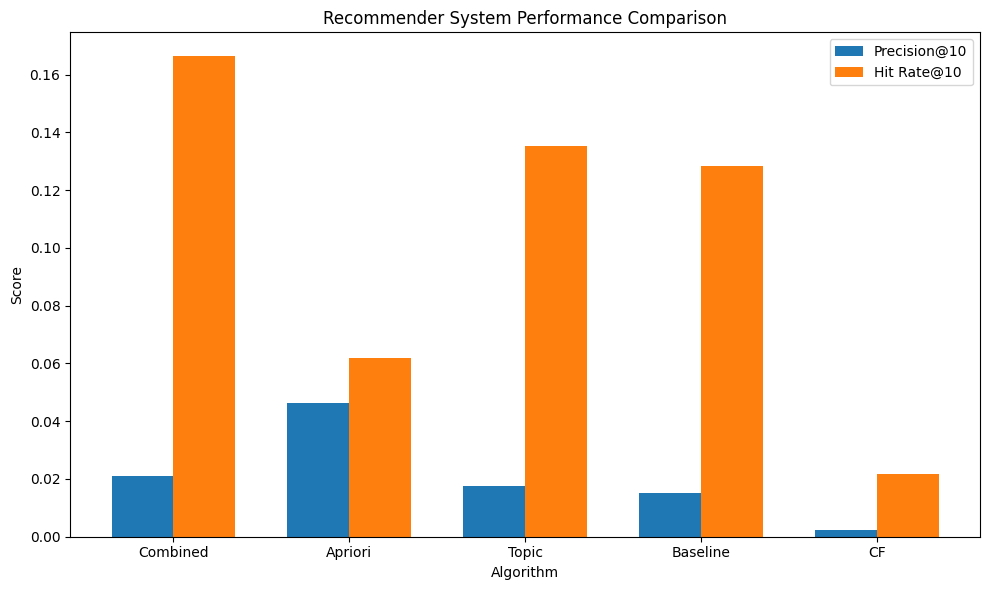

In [13]:
import matplotlib.pyplot as plt
import numpy as np

algorithms = ['Combined', 'Apriori', 'Topic', 'Baseline', 'CF']
precision = [0.0209, 0.0462, 0.0175, 0.0151, 0.0024]
hit_rate = [0.1663, 0.0618, 0.1353, 0.1284, 0.0217]

x = np.arange(len(algorithms))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, precision, width, label='Precision@10')
bars2 = ax.bar(x + width/2, hit_rate, width, label='Hit Rate@10')

ax.set_ylabel('Score')
ax.set_xlabel('Algorithm')
ax.set_xticks(x)
ax.set_xticklabels(algorithms)
ax.legend()
plt.title('Recommender System Performance Comparison')
plt.tight_layout()

In [12]:
example_user = list(test_groups.groups.keys())[0]

if example_user:
    print(f"\nExample for User: {example_user}")
    user_history = train_groups.get_group(example_user) if example_user in train_groups.groups else pd.DataFrame()

    recs, _ = get_combined_recommendations(example_user, user_history, top_n=10)
    for r in recs:
        eid = r['id']
        # fetch title if possible
        title = "Unknown"
        if eid in events_df.index.astype(str):
            title = events_df.loc[int(eid)]['title']
        
        print(f"[{r['score']:.2f}] {title} ({eid})")
        
        contribs = []
        for algo, vals in r['contributions'].items():
            norm_raw = vals['raw'] 
            w_score = vals['weighted']
            contribs.append(f"{algo}: {w_score:.2f} (norm: {norm_raw:.2f})")
        print(f"    -> {', '.join(contribs)}")
else:
    print("No valid user found in raw_trades for example.")


Example for User: 0x00000000000050ba7c429821e6d66429452ba168
[0.55] Bitcoin all time high today? (903689)
    -> topic: 0.55 (norm: 1.00)
[0.54] Bitcoin all time high by March 5? (903720)
    -> topic: 0.54 (norm: 0.98)
[0.53] Bitcoin all time high by Friday? (903583)
    -> topic: 0.53 (norm: 0.96)
[0.53] Bitcoin all time high by next Friday? (903584)
    -> topic: 0.53 (norm: 0.96)
[0.48] What price will $BTC reach in July? (11351)
    -> topic: 0.48 (norm: 0.88)
[0.47] What price will $BTC reach in May? (10525)
    -> topic: 0.47 (norm: 0.85)
[0.45] Bitcoin all time high by September 30? (43878)
    -> topic: 0.45 (norm: 0.82)
[0.13] What price will $BTC dip below before August? (11029)
    -> topic: 0.13 (norm: 0.23)
[0.10] Will Giuliani appear in court for Arizona indictment? (10699)
    -> cf: 0.10 (norm: 1.00)
[0.10] House overturns Biden's SAB 121 veto? (11433)
    -> cf: 0.10 (norm: 1.00)
